In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from names import particleLabels
from sparticleNames import SParticleNames
# sns.set() #Set style
# sns.set_style('ticks')
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.5)
# sns.set_palette(sns.color_palette("Paired"))
sns.set_palette(sns.color_palette("deep"))
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

### Open File

In [2]:
file = open("../ptools/new_run/walker1.log", "r")
lines = file.readlines()

In [3]:
def get_pmodel_dict(line, step):
    pmodel_point = line
    in1 = pmodel_point.rfind("{'masses")
    pmodel_dict = eval(pmodel_point[in1:])
    #pmodel_dict = {}
    if step == 49: 
        print("here2")
        print(pmodel_point)
    #pmodel_dict['masses'] = eval(pmodel_point[in1+6:in2])
    #pmodel_dict['decays'] = eval(pmodel_point[in3 + 5:in4])
    #pmodel_dict['ssmultipliers'] = eval(pmodel_point[in5+5:])
    #print(step, pmodel_dict)
    return pmodel_dict

def get_K_and_TL(line):
    #kline = lines[line_index+12]
    kline = line.split('[')[-1].split(',')
    pmodel_K = kline[0].split('=')[-1]
    pmodel_TL = kline[1].split('=')[-1]
    return pmodel_K, pmodel_TL



### Walk through log file

In [4]:
step = 0
pmodel_step = 0
pmodel_dict = {}
walk = {}
Steps = []
add_to_walk = False
for line in lines:
    if step == 5000: 
        print(step)
        break
    if "Protomodel: {'masses':" in line:
        line_index = lines.index(line)
        if "Best combo is" in lines[line_index+2]:# or "best combo for strategy" in lines[line_index+13]:
            #print(step)
            step = step + 1
            #print(f"{step} {line}")
            if step == 49: 
                print("here1")
                print(line)
            Steps.append(step)
            pmodel_dict = get_pmodel_dict(line, step)
            pmodel_K, pmodel_TL = get_K_and_TL(lines[line_index + 2])
            
            pmodel_dict['K'] = float(pmodel_K)
            pmodel_dict['TL'] = float(pmodel_TL)
            add_to_walk = True
            pmodel_step = step
    if f'Step {step + 1} did not converge to muhat 1.0' in line:
        #print(step)
        step = step + 1
        line_index = lines.index(line)
        pmodel_line = lines[line_index-5]
        pmodel_dict = {}
        pmodel_dict['K'] = None
        pmodel_dict['TL'] = None
        pmodel_dict['revert'] = True
        walk[step] = pmodel_dict
        continue
    #if step == 45: print(step)
    if add_to_walk and f'Step {step}/10000 finished' in line:
        #print(step)
        line_index = lines.index(line)
        if 'revert' in lines[line_index-1]: pmodel_dict['revert'] = True
        else: pmodel_dict['revert'] = False
        walk[step] = pmodel_dict
    else:
        if 'finished' in line and 'preds' not in line: 
            print("failed", line)
            print(step)
        


steps = walk.keys()
print(len(steps))
print(len(Steps))

here1
[randomWalker-14:00:11] Protomodel: {'masses': {1000022: 46.514732, 1000023: 449.803627, 1000006: 1064.6302679768894}, 'ssmultipliers': {(1000022, 1000022): 0.15544022466244445, (1000023, 1000023): 0.2212524136248159, (1000022, 1000023): 0.0, (1000006, 1000006): 1.0, (-1000006, 1000006): 1.0, (-1000006, -1000006): 1.0, (1000006, 1000022): 1.0, (-1000006, 1000022): 1.0, (1000006, 1000023): 1.0, (-1000006, 1000023): 1.0}, 'decays': {1000022: {}, 1000023: {(1000022, 25): 0.9551756317075801, (1000022, 23): 0.04482436829242002}, 1000006: {(1000022, 6): 0.23870685073619527, (1000023, 6): 0.7612931492638048}}}

here2
[randomWalker-14:00:11] Protomodel: {'masses': {1000022: 46.514732, 1000023: 449.803627, 1000006: 1064.6302679768894}, 'ssmultipliers': {(1000022, 1000022): 0.15544022466244445, (1000023, 1000023): 0.2212524136248159, (1000022, 1000023): 0.0, (1000006, 1000006): 1.0, (-1000006, 1000006): 1.0, (-1000006, -1000006): 1.0, (1000006, 1000022): 1.0, (-1000006, 1000022): 1.0, (100

In [5]:
from builder.protomodel import ProtoModel
from builder.manipulator import Manipulator

off_par = []
walk_step = []
mlsp = []
mnlsp_n, mnlsp_n3 = [],[]
mnlsp_c = []
revert_step = []
was_offshell = False
jump_on_off, jump_off_on = 0,0
particles = []
for step,w in walk.items():
    if 'masses' not in w.keys():continue
    #print(step)
    walk_step.append(step)
    ma = Manipulator(w)
    if step == 3: print(f"nTotal = {len(ma.M.particles)}")
    is_offshell = False
    particles.append(w['masses'])
    #print(w)
    mlsp.append(w['masses'][1000022])
    if 1000023 in w['masses'].keys(): 
        mnlsp_n.append(w['masses'][1000023])
        is_offshell = ma.checkIfOffshell(1000023)    
    else: mnlsp_n.append(0)
    if 1000024 in w['masses'].keys(): 
        mnlsp_c.append(w['masses'][1000024])
        is_offshell = ma.checkIfOffshell(1000024)
    else: mnlsp_c.append(0)
    if 1000025 in w['masses'].keys(): 
        mnlsp_n3.append(w['masses'][1000025])
        #is_offshell = ma.checkIfOffshell(1000025)
    else: mnlsp_n3.append(0)
    if is_offshell: 
        off_par.append(w)
        was_offshell = True
        jump_on_off += 1
    if was_offshell and not is_offshell:
        jump_off_on += 1
        was_offshell = False
    revert_step.append(w['revert'])



[manipulator:0] initializing from dictionary: X1Z, X2Z, X1W, Xt
[manipulator:0] initializing from dictionary: X1Z, X2Z, X1W
[manipulator:0] initializing from dictionary: X1Z, X2Z, X1W, Xb
nTotal = 20
[manipulator:0] initializing from dictionary: X1Z, X2Z, X1W
[manipulator:0] initializing from dictionary: X1Z, X2Z, X1W
[manipulator:0] initializing from dictionary: X1Z, X2Z, Xt
[manipulator:0] initializing from dictionary: X1Z, X1W
[manipulator:0] initializing from dictionary: X1Z, X1W, Xnumu
[manipulator:0] initializing from dictionary: X1Z, X2Z, X1W, Xb
[manipulator:0] initializing from dictionary: X1Z, X2Z, X1W
[manipulator:0] initializing from dictionary: X1Z, X2Z, Xg
[manipulator:0] initializing from dictionary: X1Z, X2Z, X1W
[manipulator:0] initializing from dictionary: X1Z, X2Z, X1W, Xnumu
[manipulator:0] initializing from dictionary: X1Z, X1W, Xg
[manipulator:0] initializing from dictionary: X1Z, X1W, Xnumu
[manipulator:0] initializing from dictionary: X1Z, X1W, X2Z
[manipulator:

### Walk in the mass space

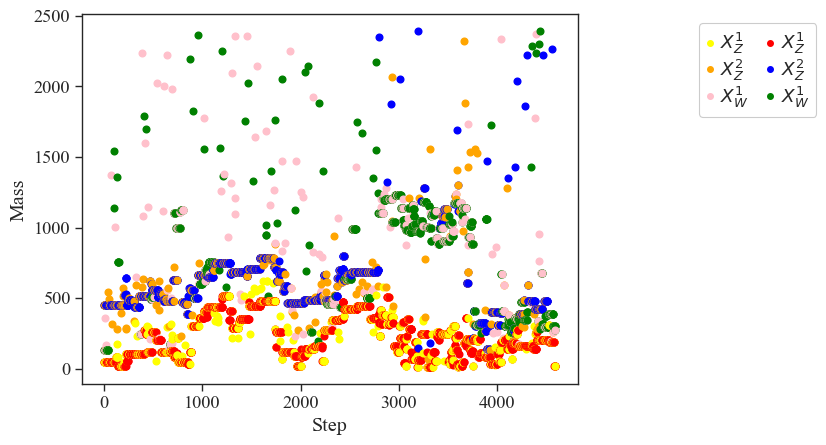

In [6]:
color_step = ['red', 'blue', 'green']
color_revert = ['yellow', 'orange', 'pink']
par_labels = ['X^{1}_{Z}', 'X^{2}_{Z}', 'X^{1}_{W}']

for i in range(len(walk_step)):
    if revert_step[i] == True:
        plt.plot(walk_step[i],mlsp[i],'o', color=color_revert[0])
        if mnlsp_n[i]!=0: plt.plot(walk_step[i], mnlsp_n[i],'o',color=color_revert[1])
        if mnlsp_c[i]!=0:plt.plot(walk_step[i], mnlsp_c[i],'o',color=color_revert[2])
    else:
        plt.plot(walk_step[i],mlsp[i],'o', color=color_step[0])
        if mnlsp_n[i]!=0:plt.plot(walk_step[i], mnlsp_n[i],'o',color=color_step[1])
        if mnlsp_c[i]!=0:plt.plot(walk_step[i], mnlsp_c[i],'o',color=color_step[2])     

plt.xlabel('Step')
plt.ylabel('Mass') 
patches = []
for i,col in enumerate(color_revert):  
    dot = mlines.Line2D([], [], color=col, marker='o', markersize=5, linewidth=0, label=rf'${par_labels[i]}$')
    patches.append(dot)
for i,col in enumerate(color_step):  
    dot = mlines.Line2D([], [], color=col, marker='o', markersize=5, linewidth=0, label=rf'${par_labels[i]}$')
    patches.append(dot)

plt.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.5, 1), framealpha=1.0,ncol=2,labelspacing=0.1, handlelength=0.4,handletextpad=0.35,markerscale=0.8,columnspacing=1.0)
plt.show()

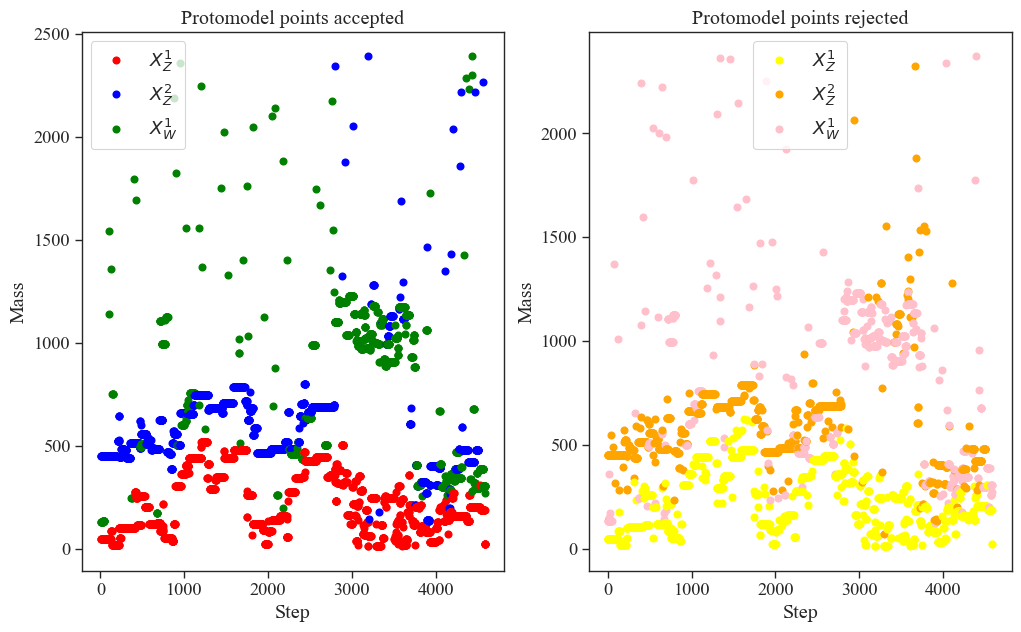

In [7]:
fig, ax = plt.subplots(1,2, figsize=(12,7))
color_revert = ['yellow', 'orange', 'pink']
color_step = ['red', 'blue', 'green']
p,q,r=0,0,0
m,n,o =0,0,0
for i in range(len(walk_step)):
    #print(i)
    if revert_step[i] == True:
        if p==0: ax[1].plot(walk_step[i],mlsp[i],'o', color=color_revert[0], label=rf'${par_labels[0]}$'); p = 1
        else: ax[1].plot(walk_step[i],mlsp[i],'o', color=color_revert[0])
        if mnlsp_n[i]!=0: 
            if q==0: ax[1].plot(walk_step[i], mnlsp_n[i],'o',color=color_revert[1], label=rf'${par_labels[1]}$'); q+=1
            else: ax[1].plot(walk_step[i], mnlsp_n[i],'o',color=color_revert[1])
        if mnlsp_c[i]!=0:
            if r==0: ax[1].plot(walk_step[i], mnlsp_c[i],'o',color=color_revert[2], label=rf'${par_labels[2]}$'); r+=1
            else:ax[1].plot(walk_step[i], mnlsp_c[i],'o',color=color_revert[2])
    else:
        if m==0:ax[0].plot(walk_step[i],mlsp[i],'o', color=color_step[0], label=rf"${par_labels[0]}$"); m+=1
        else: ax[0].plot(walk_step[i],mlsp[i],'o', color=color_step[0])
        if mnlsp_n[i]!=0:
            if n==0: ax[0].plot(walk_step[i], mnlsp_n[i],'o',color=color_step[1], label=rf'${par_labels[1]}$'); n+=1
            else: ax[0].plot(walk_step[i], mnlsp_n[i],'o',color=color_step[1])
        if mnlsp_c[i]!=0:
            if o==0: ax[0].plot(walk_step[i], mnlsp_c[i],'o',color=color_step[2], label=rf'${par_labels[2]}$'); o+=1  
            else: ax[0].plot(walk_step[i], mnlsp_c[i],'o',color=color_step[2])  

ax[0].set_xlabel('Step')
ax[0].set_ylabel('Mass')
ax[1].set_xlabel('Step')
ax[1].set_ylabel('Mass')

ax[0].set_title('Protomodel points accepted')
ax[1].set_title('Protomodel points rejected')

ax[0].legend()
ax[1].legend()

plt.show()

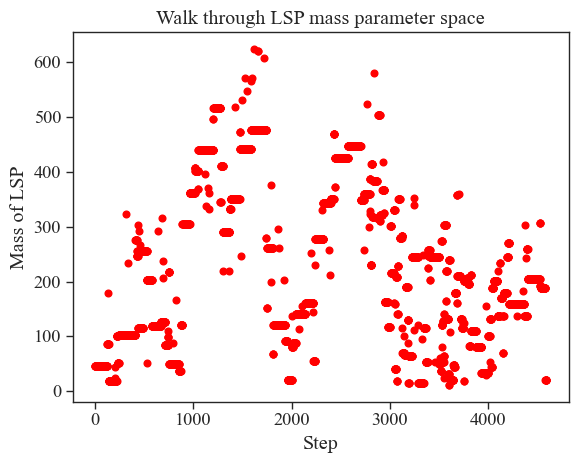

In [8]:
plt.plot(walk_step,mlsp,'o', color=color_step[0])
plt.xlabel('Step')
plt.ylabel('Mass of LSP')
plt.title('Walk through LSP mass parameter space')
plt.show()

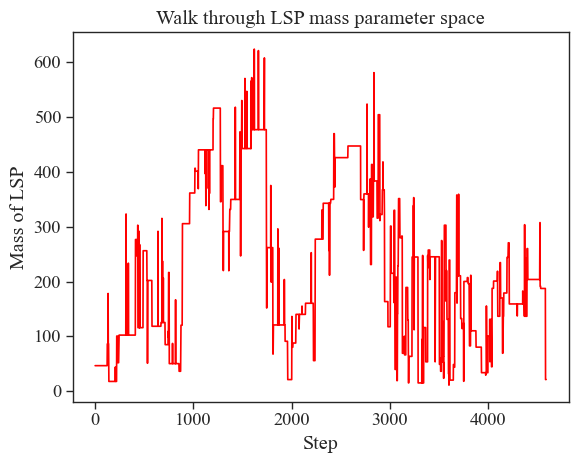

In [9]:
plt.plot(walk_step,mlsp,'-', color=color_step[0])
plt.xlabel('Step')
plt.ylabel('Mass of LSP')
plt.title('Walk through LSP mass parameter space')
plt.show()

ValueError: x and y must have same first dimension, but have shapes (2,) and (3658,)

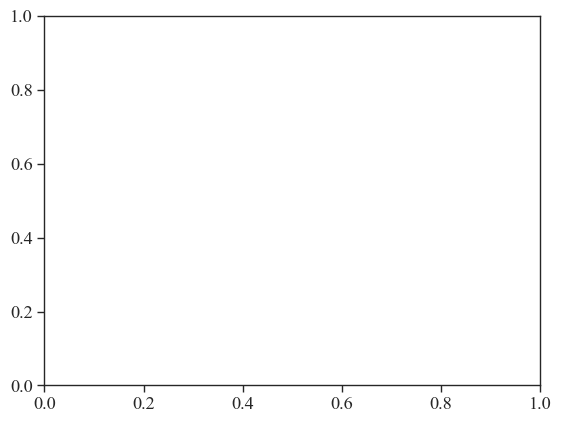

In [10]:
plt.plot(walk_step[:2],mlsp,'-o', color=color_step[0])
plt.xlabel('Step')
plt.ylabel('Mass of LSP')
plt.title('Walk through LSP mass parameter space')
plt.show()

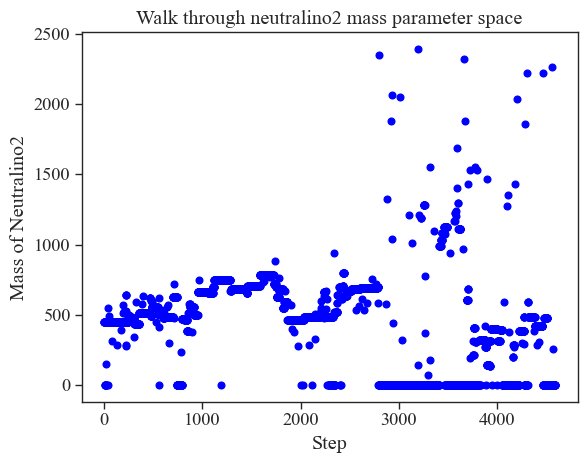

In [11]:
plt.plot(walk_step,mnlsp_n,'o', color=color_step[1])
plt.xlabel('Step')
plt.ylabel('Mass of Neutralino2')
plt.title('Walk through neutralino2 mass parameter space')
plt.show()

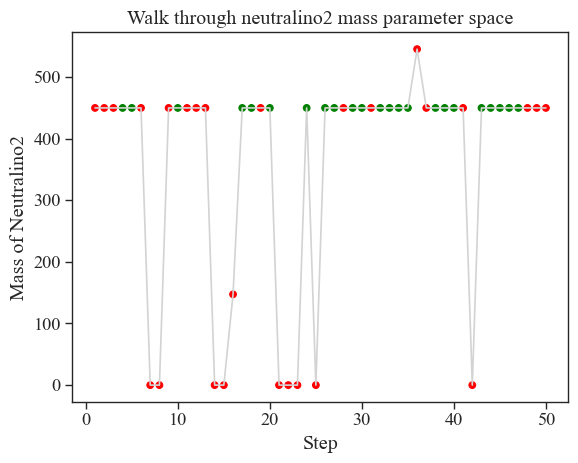

In [12]:
rev_col = ['red' if revert else 'green' for revert in revert_step]
plt.scatter(walk_step[:50],mnlsp_n[:50], color=rev_col[:50])
plt.plot(walk_step[:50],mnlsp_n[:50],'-', color='lightgray')
plt.xlabel('Step')
plt.ylabel('Mass of Neutralino2')
plt.title('Walk through neutralino2 mass parameter space')
plt.show()

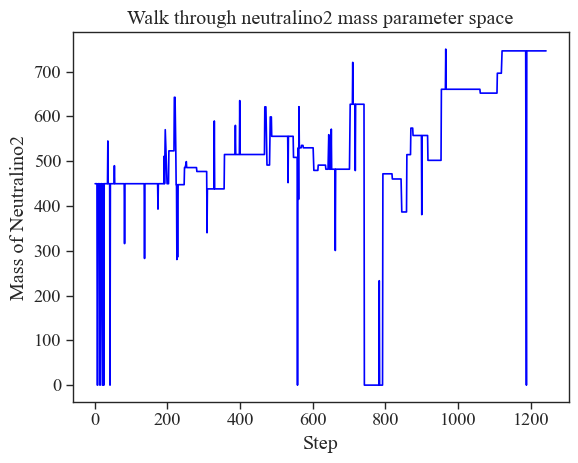

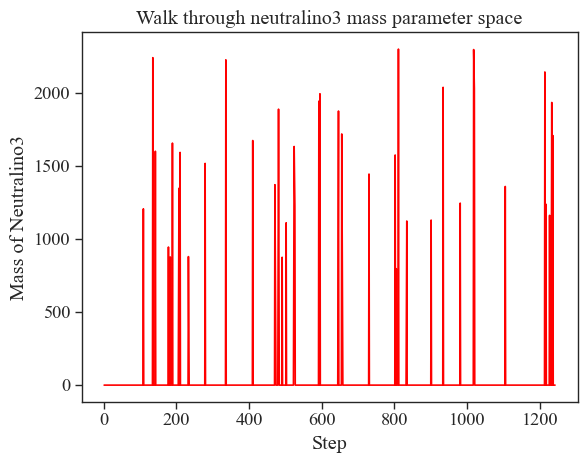

In [13]:

plt.plot(walk_step[:1000],mnlsp_n[:1000],'-', color=color_step[1])
plt.xlabel('Step')
plt.ylabel('Mass of Neutralino2')
plt.title('Walk through neutralino2 mass parameter space')
plt.show()
plt.plot(walk_step[:1000],mnlsp_n3[:1000],'-', color='red')
plt.xlabel('Step')
plt.ylabel('Mass of Neutralino3')
plt.title('Walk through neutralino3 mass parameter space')
plt.show()

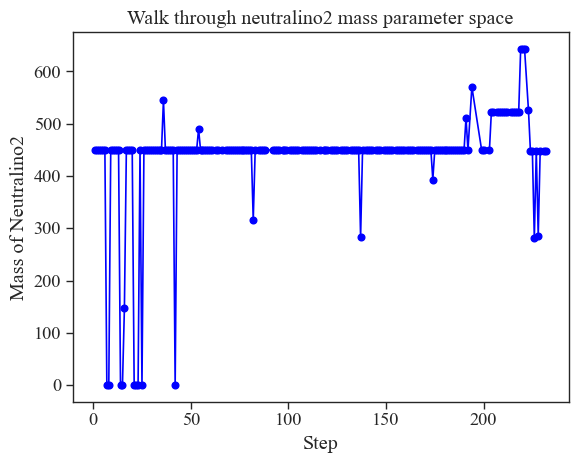

In [14]:
plt.plot(walk_step[:200],mnlsp_n[:200],'-o', color=color_step[1])
plt.xlabel('Step')
plt.ylabel('Mass of Neutralino2')
plt.title('Walk through neutralino2 mass parameter space')
plt.show()

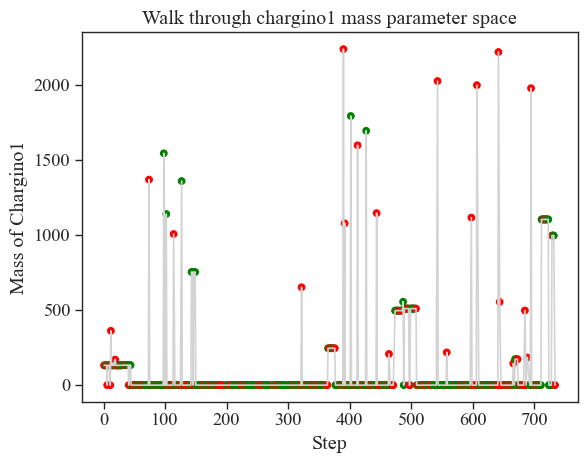

In [15]:
plt.scatter(walk_step[:600],mnlsp_c[:600], color=rev_col[:600])
plt.plot(walk_step[:600],mnlsp_c[:600],'-', color='lightgray')
plt.xlabel('Step')
plt.ylabel('Mass of Chargino1')
plt.title('Walk through chargino1 mass parameter space')
plt.show()

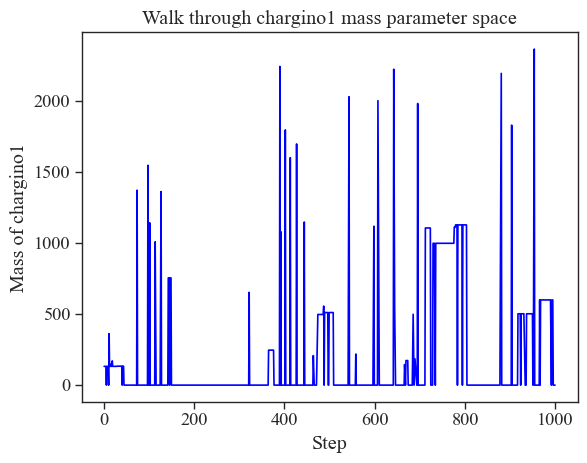

In [ ]:
plt.plot(walk_step,mnlsp_c,'-', color=color_step[1])
plt.xlabel('Step')
plt.ylabel('Mass of chargino1')
plt.title('Walk through chargino1 mass parameter space')
plt.show()

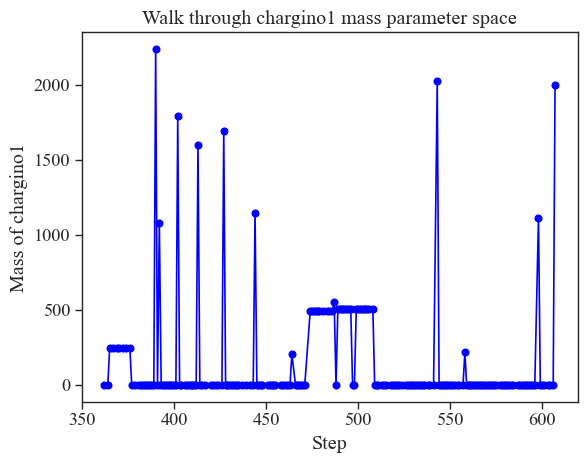

In [ ]:
plt.plot(walk_step[300:500],mnlsp_c[300:500],'-o', color=color_step[1])
plt.xlabel('Step')
plt.ylabel('Mass of chargino1')
plt.title('Walk through chargino1 mass parameter space')
plt.show()

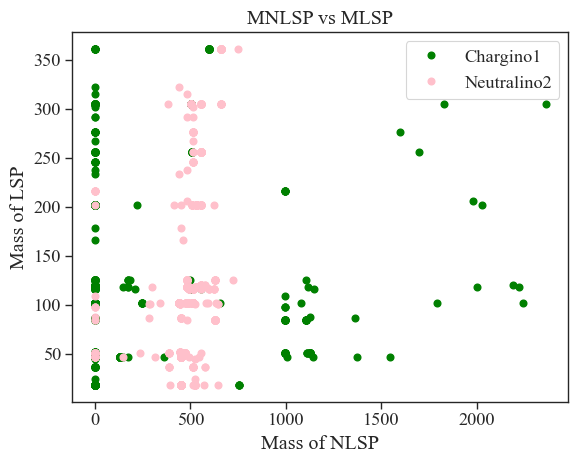

In [ ]:
plt.plot(mnlsp_c,mlsp,'o', color=color_step[2], label='Chargino1')
plt.plot(mnlsp_n,mlsp,'o',color='pink', label='Neutralino2')
plt.xlabel('Mass of NLSP')
plt.ylabel('Mass of LSP')
plt.title('MNLSP vs MLSP')
plt.legend()
plt.show()

{'masses': {1000022: 244.1441802585929, 1000024: 248.28306928393278}, 'ssmultipliers': {(1000022, 1000022): 57770.00536188442, (1000024, 1000024): 1159.3145781689095, (-1000024, 1000024): 171.23125119398918, (-1000024, -1000024): 0.015327438592639731, (1000022, 1000024): 171.23125119398918, (-1000024, 1000022): 171.23125119398918}, 'decays': {1000022: {}, 1000024: {(1000022, 11, 12): 0.1111111111111111, (1000022, 13, 14): 0.1111111111111111, (1000022, 15, 16): 0.1111111111111111, (1000022, 2, 1): 0.6666666666666666}}, 'K': 1.43, 'TL': 10.7, 'revert': True}


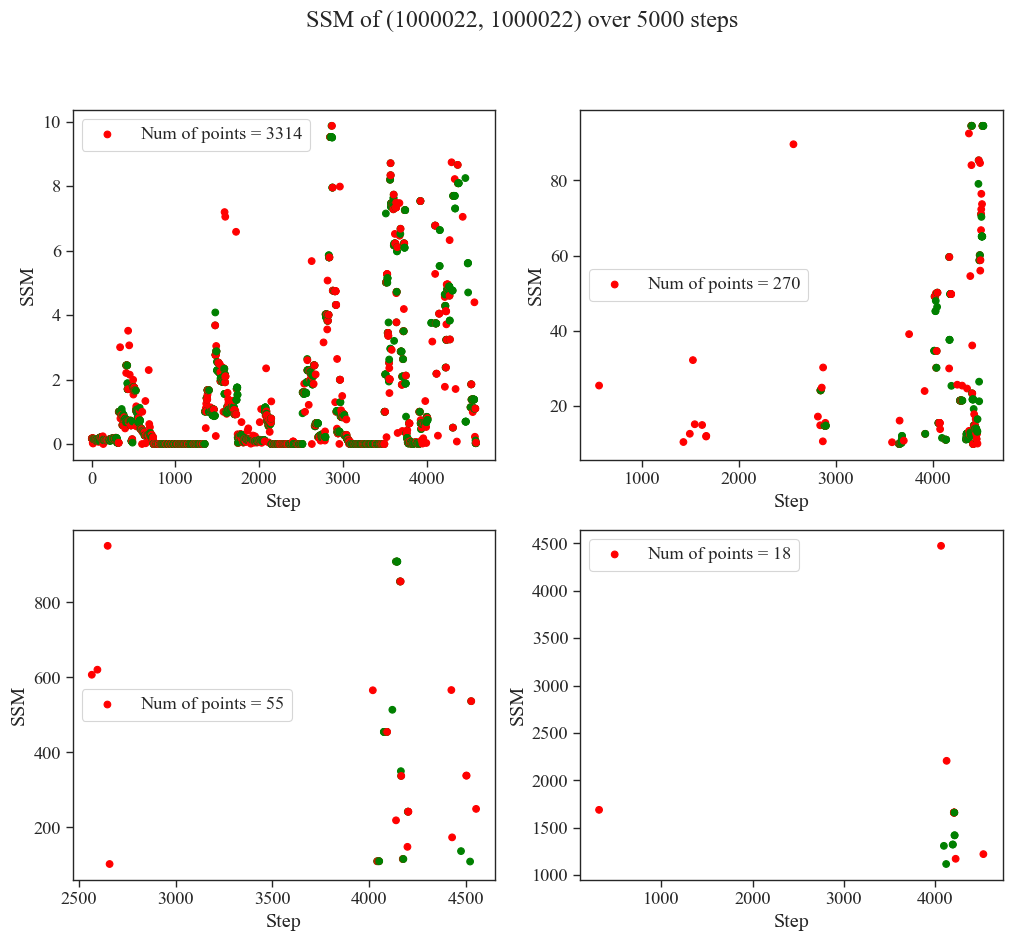

18


In [ ]:
fig, ax = plt.subplots(2,2, figsize=(12,10))
ssm_list = []
vlarge_ssm, large_ssm, mid_ssm = [],[],[]
step_list, step_vlssm, step_lssm, step_mssm = [],[],[],[]
col_small, col_mid, col_large, col_vlarge = [],[],[],[]
step_count = 0
for step,w in walk.items():
    if 'ssmultipliers' in w.keys():
        ssm = w['ssmultipliers'][(1000022, 1000022)]
        if ssm > 50000: print(w)
        elif ssm > 1000: 
            vlarge_ssm.append(ssm) 
            step_vlssm.append(step)
            if w['revert']: col = 'red'
            else: col = 'green'
            col_vlarge.append(col)
            step_count +=1
        elif ssm > 100:
            large_ssm.append(ssm) 
            step_lssm.append(step) 
            if w['revert']: col = 'red'
            else: col = 'green'
            col_large.append(col) 
        elif ssm > 10:
            mid_ssm.append(ssm) 
            step_mssm.append(step) 
            if w['revert']: col = 'red'
            else: col = 'green'
            col_mid.append(col)               
        else:
            ssm_list.append(ssm)
            step_list.append(step)
            if w['revert']: col = 'red'
            else: col = 'green'
            col_small.append(col)
        

ax[0,0].scatter(step_list, ssm_list, color=col_small, label=f'Num of points = {len(ssm_list)}')
ax[0,0].set_xlabel('Step')
ax[0,0].set_ylabel('SSM')
ax[0,0].legend()
ax[0,1].scatter(step_mssm, mid_ssm,color=col_mid, label=f'Num of points = {len(mid_ssm)}')
ax[0,1].set_xlabel('Step')
ax[0,1].set_ylabel('SSM')
ax[0,1].legend()
ax[1,0].scatter(step_lssm, large_ssm,color=col_large, label=f'Num of points = {len(large_ssm)}')
ax[1,0].set_xlabel('Step')
ax[1,0].set_ylabel('SSM')
ax[1,0].legend()
ax[1,1].scatter(step_vlssm, vlarge_ssm, color=col_vlarge, label=f'Num of points = {len(vlarge_ssm)}')
ax[1,1].set_xlabel('Step')
ax[1,1].set_ylabel('SSM')
ax[1,1].legend()

fig.suptitle('SSM of (1000022, 1000022) over 5000 steps')

plt.show()
print(step_count)

(array([ 83.,  17.,  54.,  89., 123.,  56.,  32.,  49.,  12.,  20.,  15.,
         21.,  31.,   3.,   2.,   0.,   0.,   1.,   0.,   0.,   8.,   1.,
          0.,  10.,   3.,  20.,   0.,   0.,   1.,   2.,   0.,   3.,   1.,
          0.,   8.,   2.,   3.,   1.,   0.,   9.,   1.,   2.,   1.,   3.,
          0.,   0.,   0.,   1.,   0.,   8.]),
 array([2.93719486e-08, 1.97438711e-06, 3.91940227e-06, 5.86441744e-06,
        7.80943260e-06, 9.75444776e-06, 1.16994629e-05, 1.36444781e-05,
        1.55894932e-05, 1.75345084e-05, 1.94795236e-05, 2.14245387e-05,
        2.33695539e-05, 2.53145691e-05, 2.72595842e-05, 2.92045994e-05,
        3.11496145e-05, 3.30946297e-05, 3.50396449e-05, 3.69846600e-05,
        3.89296752e-05, 4.08746904e-05, 4.28197055e-05, 4.47647207e-05,
        4.67097358e-05, 4.86547510e-05, 5.05997662e-05, 5.25447813e-05,
        5.44897965e-05, 5.64348117e-05, 5.83798268e-05, 6.03248420e-05,
        6.22698571e-05, 6.42148723e-05, 6.61598875e-05, 6.81049026e-05,
        7.

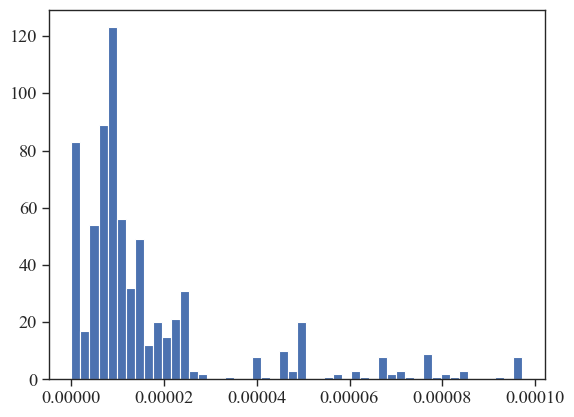

In [ ]:
ssm_array = np.array(ssm_list)
vsmall_ssm = ssm_array[np.where(ssm_array < 1e-04)]
plt.hist(vsmall_ssm, bins=50)

### Offshell space

In [ ]:
for par in off_par:
    print(par['masses'])
    #print(par['ssmultipliers'])

{1000022: 201.99370491880958, 1000024: 218.27126974897}
{1000022: 118.40350071283154, 1000023: 482.1996511231912, 1000024: 144.61163662974775}
{1000022: 118.40350071283154, 1000023: 482.1996511231912, 1000024: 172.60815473726862}
{1000022: 118.40350071283154, 1000023: 482.1996511231912, 1000024: 172.60815473726862, 1000037: 1334.9117650034027}
{1000022: 125.30749382588101, 1000023: 482.1996511231912, 1000024: 172.60815473726862}
{1000022: 125.30749382588101, 1000023: 482.1996511231912, 1000024: 172.60815473726862}
{1000022: 125.30749382588101, 1000023: 482.1996511231912, 1000024: 172.60815473726862, 1000012: 375.8918531939208}
{1000022: 125.30749382588101, 1000023: 482.1996511231912, 1000024: 184.46717664138535}
{1000022: 305.6343443616599, 1000023: 380.7593587768961}


In [ ]:
jump_off_on, jump_on_off

(5, 9)

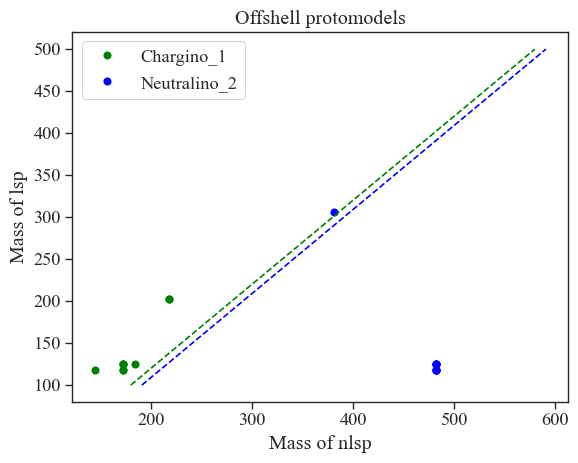

In [ ]:
import numpy as np
i,j = 0,0
x = np.linspace(100, 500, 50)
y_n = x + 91
y_c = x + 80
for par in off_par:
    
    if 1000023 in par['masses'].keys(): 
        mass_lsp = par['masses'][1000022]
        mass_nlsp_n = par['masses'][1000023]
        if i==0: 
            plt.plot(mass_nlsp_n,mass_lsp,'o', color='blue', label='Neutralino_2')
            i+=1
        plt.plot(mass_nlsp_n,mass_lsp,'o', color='blue')
    if 1000024 in par['masses'].keys(): 
        mass_lsp = par['masses'][1000022]
        mass_nlsp_c = par['masses'][1000024]
        if j==0: 
            plt.plot(mass_nlsp_c,mass_lsp,'o', color='green', label='Chargino_1') 
            j+=1
        plt.plot(mass_nlsp_c,mass_lsp,'o', color='green')
plt.plot(y_n,x,'--', color='blue')
plt.plot(y_c,x,'--', color='green')
plt.xlabel("Mass of nlsp")
plt.ylabel("Mass of lsp")
plt.title("Offshell protomodels")
plt.legend()
plt.show()

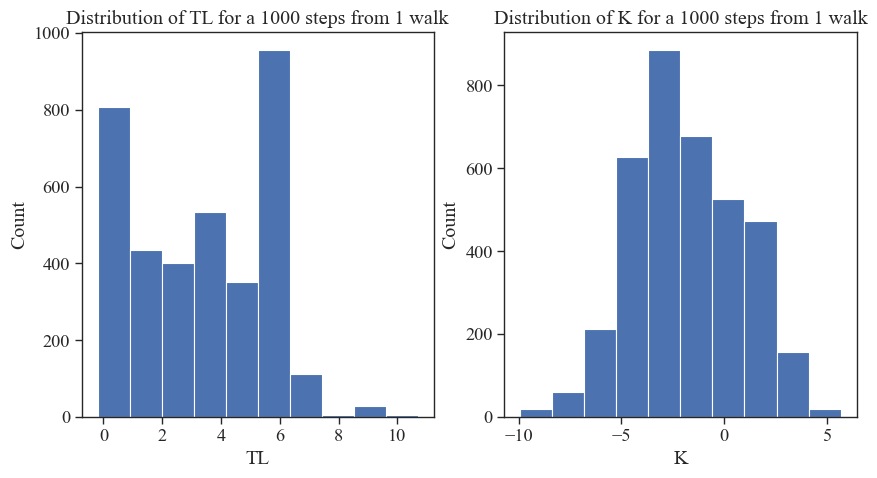

In [16]:
#Distribution of TL and K
fig, ax = plt.subplots(1,2, figsize=(10,5))
TL_list = []
for step,w in walk.items():
    if w['TL']:TL_list.append(w['TL'])

#TL_list
ax[0].hist(TL_list)
ax[0].set_xlabel('TL')
ax[0].set_ylabel('Count')
ax[0].set_title('Distribution of TL for a 1000 steps from 1 walk')


K_list = []
for step,w in walk.items():
    if w['K']:K_list.append(w['K'])

#K_list
ax[1].hist(K_list)
ax[1].set_xlabel('K')
ax[1].set_ylabel('Count')
ax[1].set_title('Distribution of K for a 1000 steps from 1 walk')
plt.show()
#T_{L} = -2log(L0/L1)
#K as a function of step
#all mass shades 

Text(0.5, 1.0, "K as a func of step starting from a ' good ' protomodel")

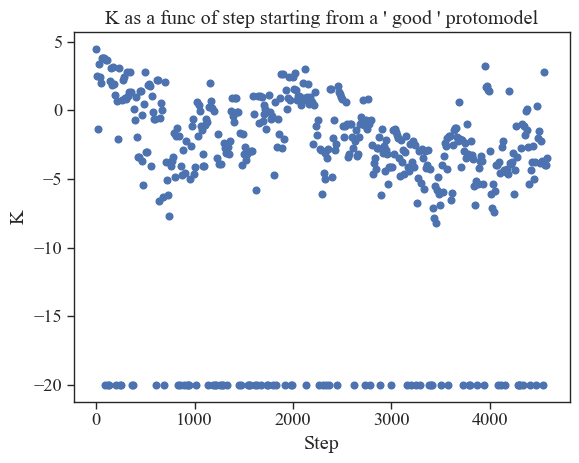

In [17]:
K_list = []
step_list = []
for step,w in walk.items():
    if w['K']:K_list.append(w['K'])
    else: K_list.append(-20)
    step_list.append(step)

plt.plot(step_list[::10], K_list[::10],'o')
plt.xlabel('Step')
plt.ylabel('K')
plt.title("K as a func of step starting from a \' good \' protomodel")

Text(0.5, 1.0, "TL as a func of step starting from a ' good ' protomodel")

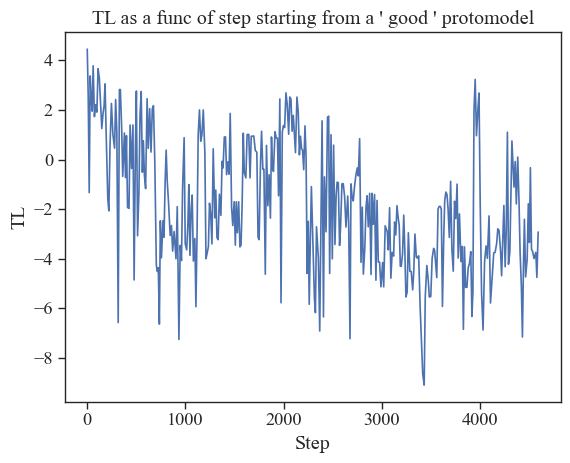

In [19]:
K_list = []
step_list = []
for step,w in walk.items():
    if w['TL']:
        K_list.append(w['K'])
        step_list.append(step)
    else: continue
    

plt.plot(step_list[::10], K_list[::10],'-')
plt.xlabel('Step')
plt.ylabel('TL')
plt.title("TL as a func of step starting from a \' good \' protomodel")

In [ ]:
#Set colors:
allPids = [1000022, 1000006, 1000001, 1000021, 1000012, 1000023, 
            1000013, 2000006, 1000011, 1000005, 1000014, 1000004, 1000015, 1000016, 1000024]
namer = SParticleNames ( susy = False )
colors = sns.color_palette('deep',n_colors=len(namer.xIDs))

#Replace default colors:
pnames = {pid:namer.name(pid) for pid in allPids}

colorDict = dict(zip(allPids,colors))
colorDict[1000002] = colorDict[1000001]
colorDict[1000003] = colorDict[1000001]
colorDict[1000004] = colorDict[1000001]

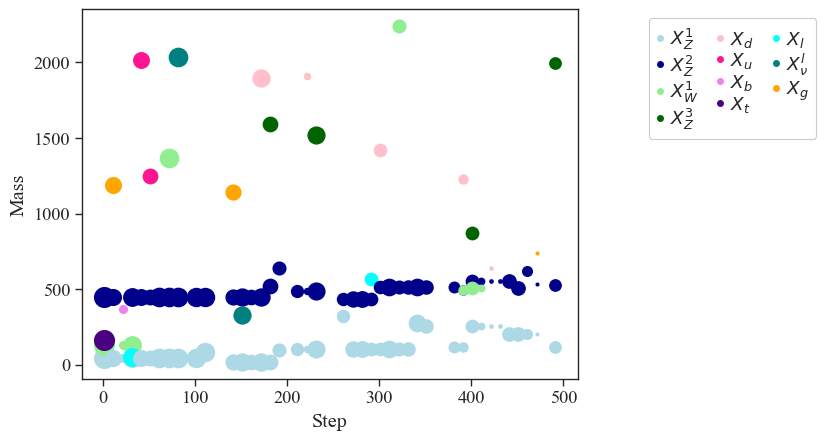

In [ ]:

cols = {1000022: 'lightblue', 1000023: 'darkblue', 1000024: 'lightgreen',1000025:'darkgreen', 1000021: 'orange', 1000001: 'pink', 1000002: 'deeppink', 1000003: 'pink', 1000004: 'deeppink', 1000005: 'violet', 1000006: 'indigo', 1000011: 'cyan', 1000012: 'teal', 1000013: 'cyan', 1000014: 'teal', 1000015: 'cyan', 1000016: 'teal'}
for i in range(0,500, 10):
    if not walk[i+1]['K']: continue
    K = (walk[i+1]['K'] + 5)*1.5
    for par in particles[i].keys():
        col = 'gray'
        mass = particles[i][par]
        if par in cols.keys(): col = cols[par]
        else: print(f"{par} col not assigned")
        plt.plot(i+1, mass, 'o', markersize=K, color=col)

names = { 1000022: "X^{1}_{Z}", 1000023: "X^{2}_{Z}", 1000024: "X^{1}_{W}", 1000025: "X^{3}_{Z}", 1000001: "X_{d}", 1000002: "X_{u}", 1000005: "X_{b}", 1000006: "X_{t}",1000011: "X_{l}", 1000012: "X_{\\nu}^{l}", 1000021: "X_{g}"}
patches = []
for par, name in names.items():
    col = cols[par]
    dot = mlines.Line2D([], [], color=col, marker='o', markersize=5, linewidth=0, label=rf'${name}$')
    patches.append(dot)

plt.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.5, 1), framealpha=1.0,ncol=3,labelspacing=0.1, handlelength=0.4,handletextpad=0.35,markerscale=0.8,columnspacing=1.0)
plt.xlabel("Step")
plt.ylabel("Mass")
plt.show()

In [ ]:
import random
mu = 1.0 - 0.7/15.0
ran_mu = random.gauss(mu , 0.5) 
print(ran_mu)
ran_mu < 5/20

1.1185755723071384


False

In [ ]:
while i<20:  
    fig, ax = plt.subplots(ncols=5, figsize=(15, 2))
    for j in range(5):
        check_point = nUnfrozen[i]/20
        colors = ['green' if rm > check_point else 'red' for rm in ran_mu]
        ax[j].scatter(TL_list, ran_mu,c=colors)
        ax[j].axhline(check_point, label=f'{check_point}')
        ax[j].set(xlabel='TL', ylabel='points',title=f'nUnfrozen ={nUnfrozen[i]}')
        ax[j].legend()
        i += 1

plt.show()

### Dependence on nUnfrozen and TL for unfreezing a particle

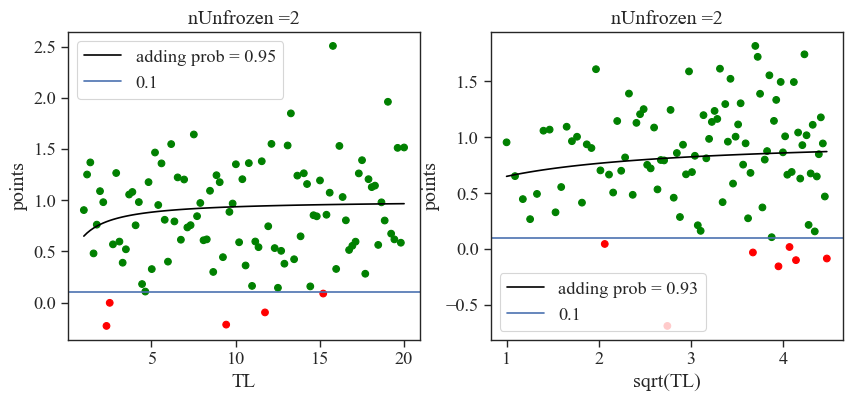

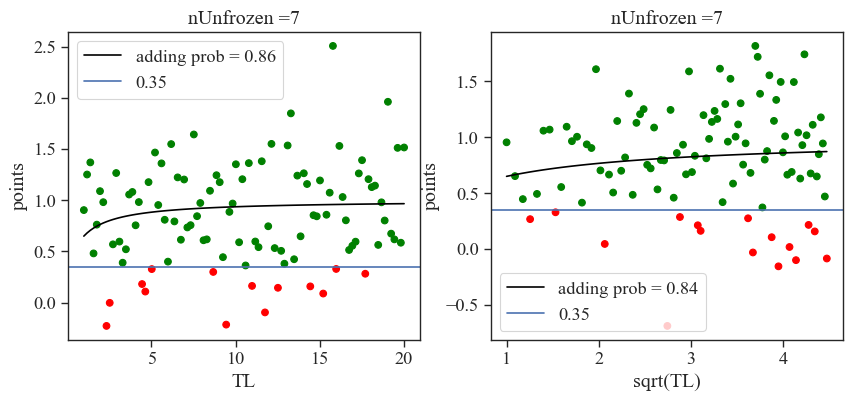

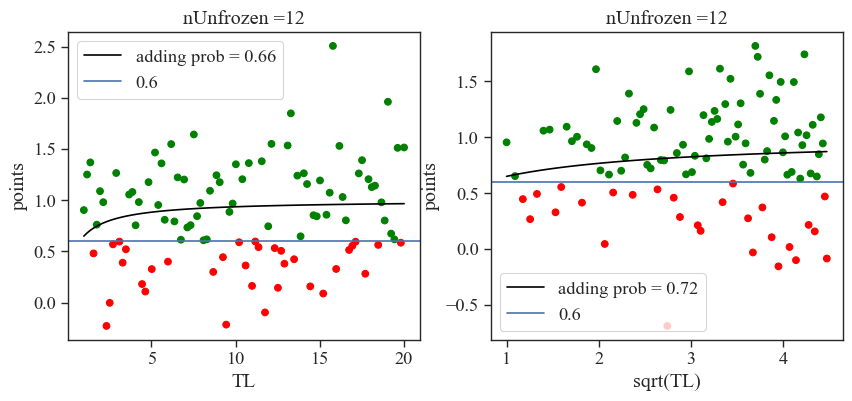

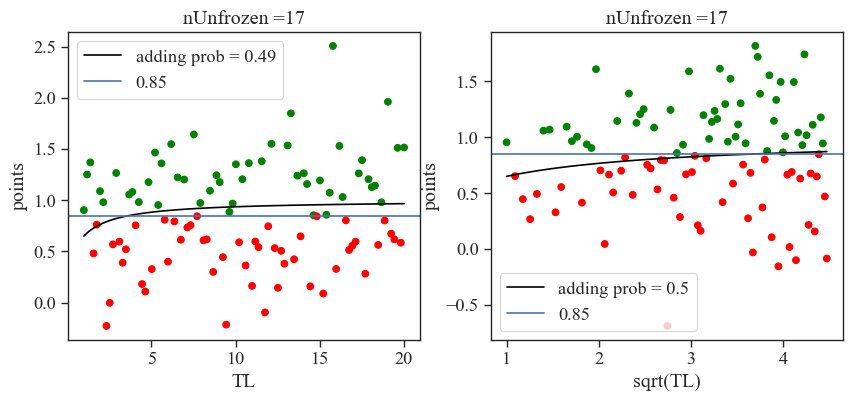

In [ ]:
TL_list = np.linspace(1.0, 20, 100)
nUnfrozen = np.arange(2, 21, step=5)
import numpy as np
steps = 1000
#fig, ax = plt.subplots(4,5, figsize=(20, 10))
muvals = [1.0 - 0.7/(tl+1) for tl in TL_list]
mu_sqrt = [1.0 - 0.7/(np.sqrt(tl)+1) for tl in TL_list]
ran_mu = [random.gauss(mu,0.5) for mu in muvals]
ran_sqrt = [random.gauss(mu,0.5) for mu in mu_sqrt]
ran = [ran_mu, ran_sqrt]
mus = [muvals, mu_sqrt]
tls = [TL_list, np.sqrt(TL_list)]
labels = ['TL', 'sqrt(TL)']
i=0
while i<len(nUnfrozen):  
    fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
    for j in range(2):
        check_point = nUnfrozen[i]/20
        colors = ['green' if rm >= check_point else 'red' for rm in ran[j]]
        acc = [rm for rm in ran[j] if rm >= check_point]
        prob_ufr = len(acc)/100
        ax[j].scatter(tls[j], ran[j],c=colors)
        ax[j].plot(tls[j], mus[j], color='black', label=f'adding prob = {prob_ufr}')
        ax[j].axhline(check_point, label=f'{check_point}')
        ax[j].set(xlabel=labels[j], ylabel='points',title=f'nUnfrozen ={nUnfrozen[i]}')
        ax[j].legend()
    i += 1

plt.show()

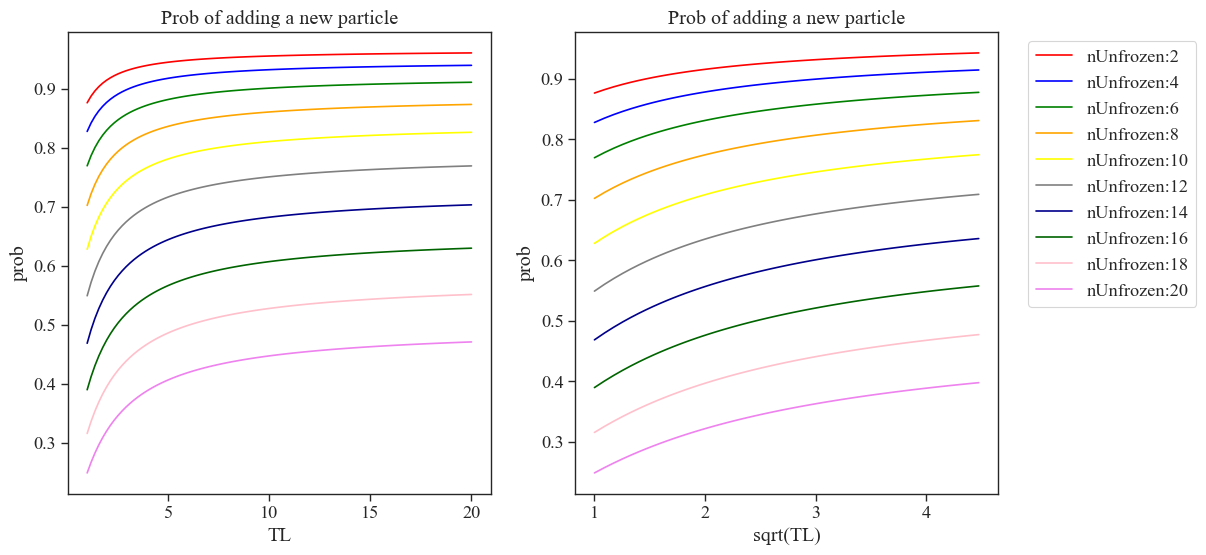

In [ ]:
#bernoulli disb
muvals = np.linspace(-0.5,1.5,100)
check_points = [nu/20 for nu in range(2,21, 2)]
nUnfrozen = np.arange(2,21,2)
colors = ['r', 'b', 'g', 'orange', 'yellow', 'gray', 'darkblue', 'darkgreen', 'pink', 'violet', 'indigo']
mu_dx = muvals[1] - muvals[0]

fig, ax  = plt.subplots(ncols=2, figsize=(12,6))
for j,t in enumerate(tls):
    for i,ck in enumerate(check_points):
        p_add_disb = []
        for m in mus[j]:
            #gauss_rand = norm.rvs(mus[0][0],0.5,100)
            #p_not_add = sum([gauss.pdf(gr,mus[0][0],0.5) for gr in gauss_rand if gr<check_point])
            p_not_add = sum([norm.pdf(mu,m,0.5)*mu_dx for mu in muvals if mu<ck])
            p_add = 1.0 - p_not_add
            p_add_disb.append(p_add)

        ax[j].plot(tls[j], p_add_disb, color=colors[i], label=f'nUnfrozen:{nUnfrozen[i]}')
    ax[j].set(xlabel=labels[j], ylabel='prob', title='Prob of adding a new particle')

ax[1].legend(bbox_to_anchor=(1.05, 1))
'''
plt.xlabel('TL')
plt.ylabel('prob')
plt.title('Prob of adding a new particle')
plt.legend(bbox_to_anchor=(1.05, 1))
'''
plt.show()

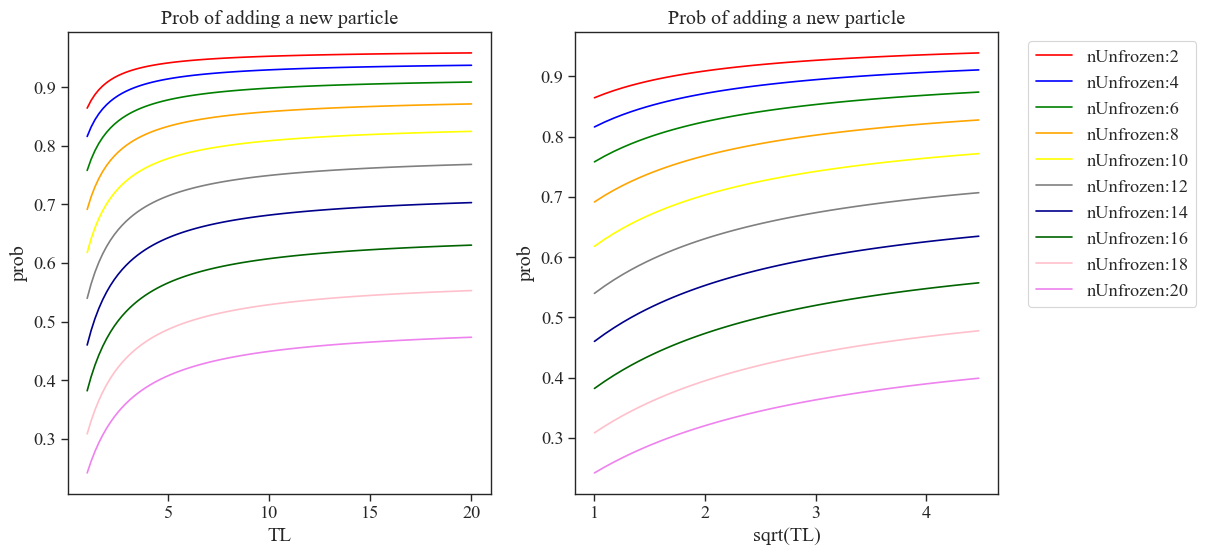

In [ ]:
TL_list = np.linspace(1.0, 20, 100)

import numpy as np
steps = 1000
#fig, ax = plt.subplots(4,5, figsize=(20, 10))
muvals = [1.0 - 0.7/(tl+1) for tl in TL_list]
mu_sqrt = [1.0 - 0.7/(np.sqrt(tl)+1) for tl in TL_list]
ran_mu = [random.gauss(mu,0.5) for mu in muvals]
ran_sqrt = [random.gauss(mu,0.5) for mu in mu_sqrt]
ran = [ran_mu, ran_sqrt]
mus = [muvals, mu_sqrt]
tls = [TL_list, np.sqrt(TL_list)]
labels = ['TL', 'sqrt(TL)']

muvals = np.linspace(-0.5,1.5,100)
check_points = [nu/20 for nu in range(2,21, 2)]
nUnfrozen = np.arange(2,21,2)
colors = ['r', 'b', 'g', 'orange', 'yellow', 'gray', 'darkblue', 'darkgreen', 'pink', 'violet', 'indigo']
mu_dx = muvals[1] - muvals[0]

from scipy.integrate import quad
def integrand(x, mu):
    return norm.pdf(x, mu, 0.5)

fig, ax  = plt.subplots(ncols=2, figsize=(12,6))
for j,t in enumerate(tls):
    for i,ck in enumerate(check_points):
        p_add_disb = []
        for m in mus[j]:
            #gauss_rand = norm.rvs(mus[0][0],0.5,100)
            #p_not_add = sum([gauss.pdf(gr,mus[0][0],0.5) for gr in gauss_rand if gr<check_point])
            p_not_add = sum([norm.pdf(mu,m,0.5)*mu_dx for mu in muvals if mu<ck])
            p_add = 1.0 - p_not_add
            p_add = quad(integrand, ck, np.inf, args=(m))[0]
            p_add_disb.append(p_add)

        ax[j].plot(tls[j], p_add_disb, color=colors[i], label=f'nUnfrozen:{nUnfrozen[i]}')
    ax[j].set(xlabel=labels[j], ylabel='prob', title='Prob of adding a new particle')

ax[1].legend(bbox_to_anchor=(1.05, 1))
'''
plt.xlabel('TL')
plt.ylabel('prob')
plt.title('Prob of adding a new particle')
plt.legend(bbox_to_anchor=(1.05, 1))
'''
plt.show()

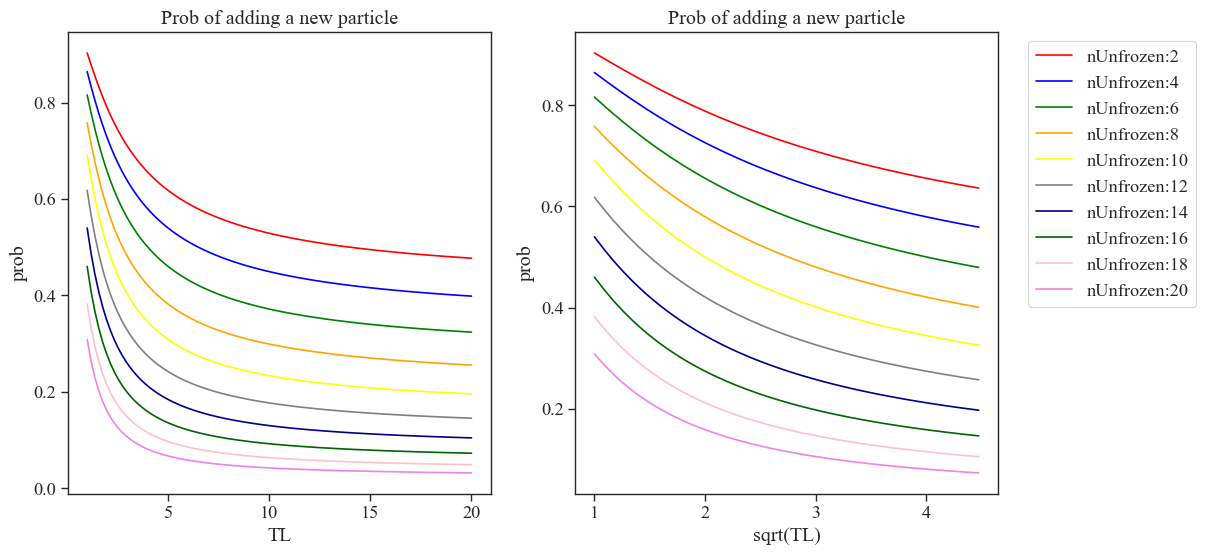

In [ ]:
TL_list = np.linspace(1.0, 20, 100)

import numpy as np
steps = 1000
#fig, ax = plt.subplots(4,5, figsize=(20, 10))
muvals = [1.5/(tl+1) for tl in TL_list]
mu_sqrt = [1.5/(np.sqrt(tl)+1) for tl in TL_list]
ran_mu = [random.gauss(mu,0.5) for mu in muvals]
ran_sqrt = [random.gauss(mu,0.5) for mu in mu_sqrt]
ran = [ran_mu, ran_sqrt]
mus = [muvals, mu_sqrt]
tls = [TL_list, np.sqrt(TL_list)]
labels = ['TL', 'sqrt(TL)']

muvals = np.linspace(-0.5,1.5,100)
check_points = [nu/20 for nu in range(2,21, 2)]
nUnfrozen = np.arange(2,21,2)
colors = ['r', 'b', 'g', 'orange', 'yellow', 'gray', 'darkblue', 'darkgreen', 'pink', 'violet', 'indigo']
mu_dx = muvals[1] - muvals[0]

from scipy.integrate import quad
def integrand(x, mu):
    return norm.pdf(x, mu, 0.5)

fig, ax  = plt.subplots(ncols=2, figsize=(12,6))
for j,t in enumerate(tls):
    for i,ck in enumerate(check_points):
        p_add_disb = []
        for m in mus[j]:
            #gauss_rand = norm.rvs(mus[0][0],0.5,100)
            #p_not_add = sum([gauss.pdf(gr,mus[0][0],0.5) for gr in gauss_rand if gr<check_point])
            p_not_add = sum([norm.pdf(mu,m,0.5)*mu_dx for mu in muvals if mu<ck])
            p_add = 1.0 - p_not_add
            p_add = quad(integrand, ck, np.inf, args=(m))[0]
            p_add_disb.append(p_add)

        ax[j].plot(tls[j], p_add_disb, color=colors[i], label=f'nUnfrozen:{nUnfrozen[i]}')
    ax[j].set(xlabel=labels[j], ylabel='prob', title='Prob of adding a new particle')

ax[1].legend(bbox_to_anchor=(1.05, 1))
'''
plt.xlabel('TL')
plt.ylabel('prob')
plt.title('Prob of adding a new particle')
plt.legend(bbox_to_anchor=(1.05, 1))
'''
plt.show()

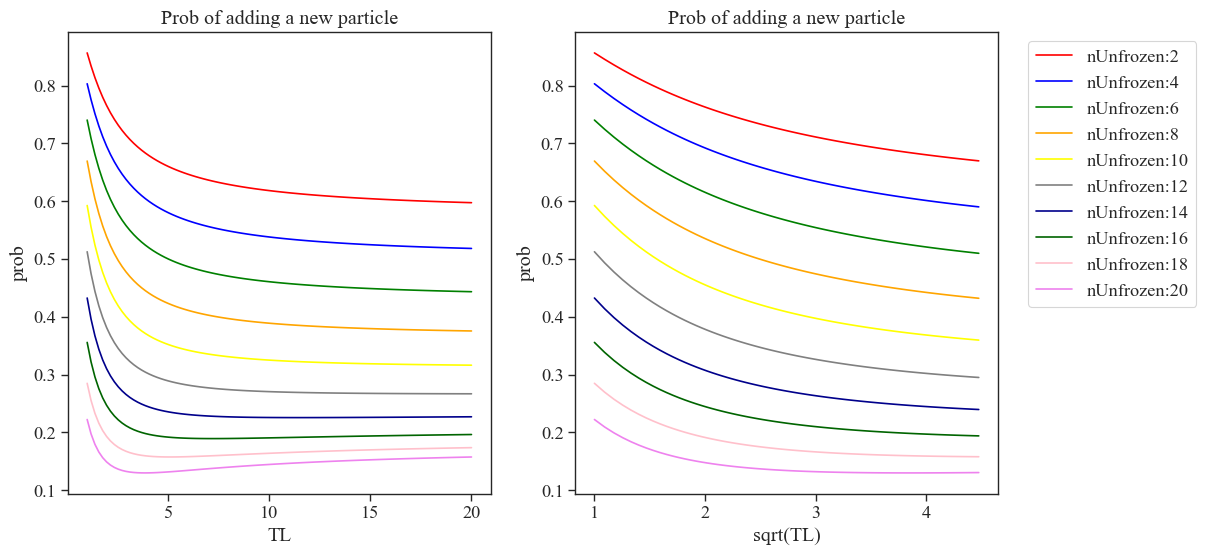

In [ ]:
TL_list = np.linspace(1.0, 20, 100)

import numpy as np
steps = 1000
#fig, ax = plt.subplots(4,5, figsize=(20, 10))
muvals = [1.2/(tl+1) for tl in TL_list]
mu_sqrt = [1.2/(np.sqrt(tl)+1) for tl in TL_list]
ran_mu = [random.gauss(mu,0.5) for mu in muvals]
ran_sqrt = [random.gauss(mu,0.5) for mu in mu_sqrt]
ran = [ran_mu, ran_sqrt]
mus = [muvals, mu_sqrt]
tls = [TL_list, np.sqrt(TL_list)]
labels = ['TL', 'sqrt(TL)']

muvals = np.linspace(-0.5,1.5,100)
check_points = [nu/20 for nu in range(2,21, 2)]
nUnfrozen = np.arange(2,21,2)
colors = ['r', 'b', 'g', 'orange', 'yellow', 'gray', 'darkblue', 'darkgreen', 'pink', 'violet', 'indigo']
mu_dx = muvals[1] - muvals[0]

fig, ax  = plt.subplots(ncols=2, figsize=(12,6))
for j,t in enumerate(tls):
    for i,ck in enumerate(check_points):
        p_add_disb = []
        for m in mus[j]:
            #gauss_rand = norm.rvs(mus[0][0],0.5,100)
            #p_not_add = sum([gauss.pdf(gr,mus[0][0],0.5) for gr in gauss_rand if gr<check_point])
            p_not_add = sum([norm.pdf(mu,m,0.5)*mu_dx for mu in muvals if mu<ck])
            p_add = 1.0 - p_not_add
            p_add_disb.append(p_add)

        ax[j].plot(tls[j], p_add_disb, color=colors[i], label=f'nUnfrozen:{nUnfrozen[i]}')
    ax[j].set(xlabel=labels[j], ylabel='prob', title='Prob of adding a new particle')

ax[1].legend(bbox_to_anchor=(1.05, 1))
'''
plt.xlabel('TL')
plt.ylabel('prob')
plt.title('Prob of adding a new particle')
plt.legend(bbox_to_anchor=(1.05, 1))
'''
plt.show()

In [ ]:
TL = - 2log L0/L1
K = Tl + penalty_for_complexity


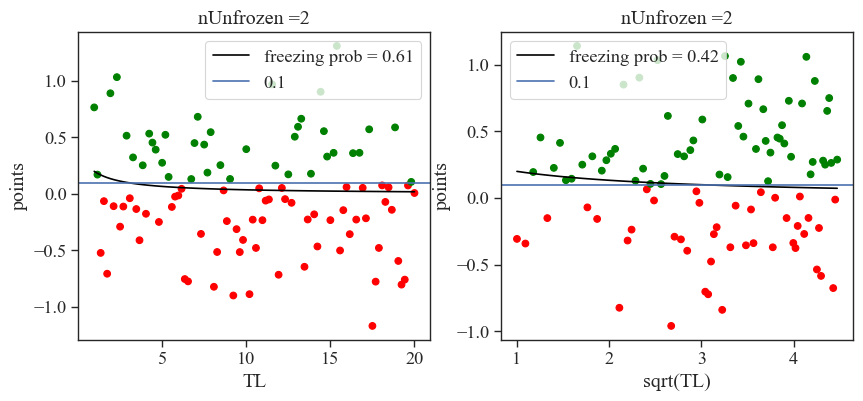

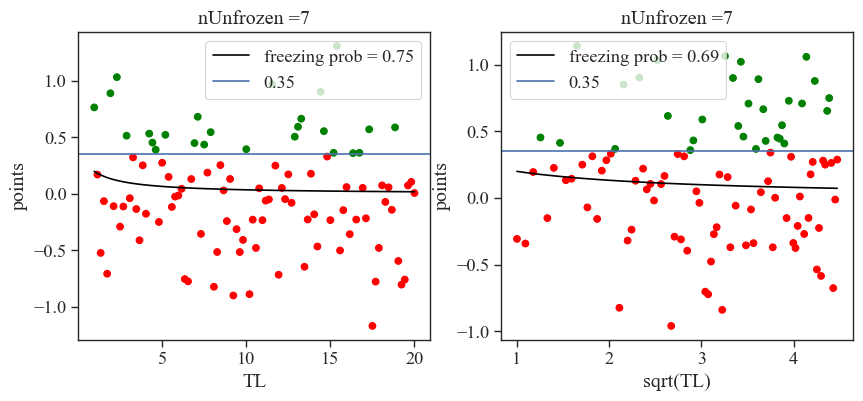

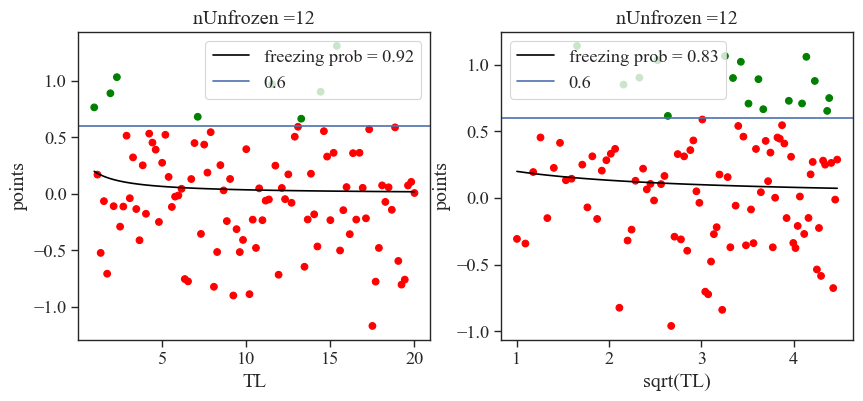

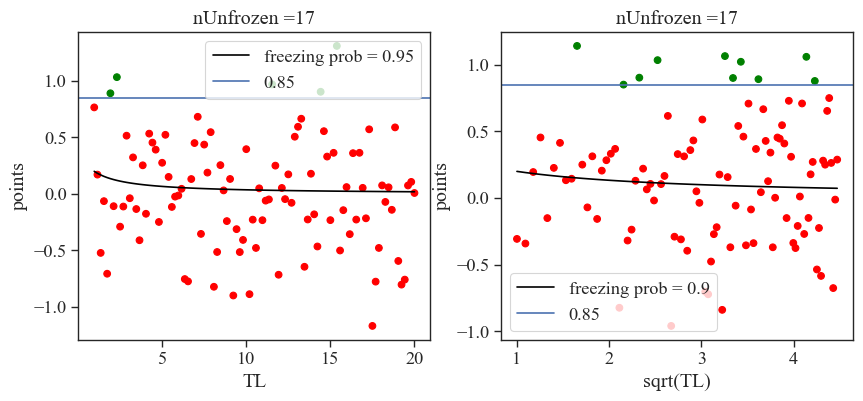

In [ ]:
TL_list = np.linspace(1.0, 20, 100)
nUnfrozen = np.arange(2, 21, step=5)
import numpy as np
steps = 1000
#fig, ax = plt.subplots(4,5, figsize=(20, 10))
muvals = [0.4/(tl+1) for tl in TL_list]
mu_sqrt = [0.4/(np.sqrt(tl)+1) for tl in TL_list]
ran_mu = [random.gauss(mu,0.5) for mu in muvals]
ran_sqrt = [random.gauss(mu,0.5) for mu in mu_sqrt]
ran = [ran_mu, ran_sqrt]
mus = [muvals, mu_sqrt]
tls = [TL_list, np.sqrt(TL_list)]
labels = ['TL', 'sqrt(TL)']
i=0
while i<len(nUnfrozen):  
    fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
    for j in range(2):
        check_point = nUnfrozen[i]/20
        colors = ['green' if rm > check_point else 'red' for rm in ran[j]]
        freeze = [rm for rm in ran[j] if rm <= check_point]
        prob_fr = len(freeze)/100
        ax[j].scatter(tls[j], ran[j],c=colors)
        ax[j].plot(tls[j], mus[j], color='black', label=f'freezing prob = {prob_fr}')
        ax[j].axhline(check_point, label=f'{check_point}')
        ax[j].set(xlabel=labels[j], ylabel='points',title=f'nUnfrozen ={nUnfrozen[i]}')
        ax[j].legend()
    i += 1

plt.show()

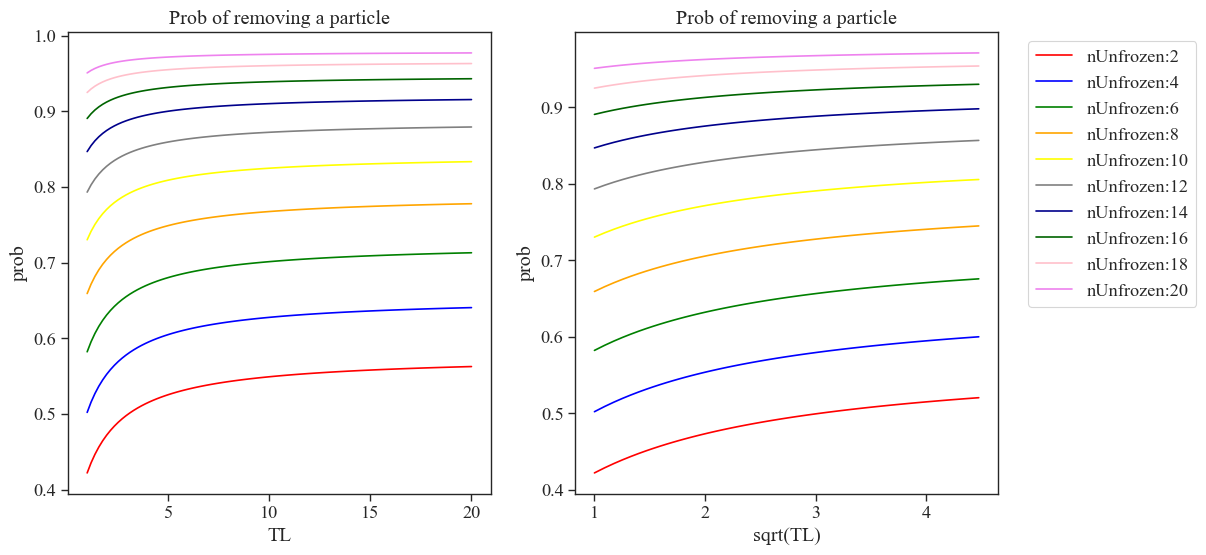

In [ ]:
muvals = np.linspace(-0.5,1.5,100)
check_points = [nu/20 for nu in range(2,21, 2)]
nUnfrozen = np.arange(2,21,2)
colors = ['r', 'b', 'g', 'orange', 'yellow', 'gray', 'darkblue', 'darkgreen', 'pink', 'violet', 'indigo']
mu_dx = muvals[1] - muvals[0]

fig, ax  = plt.subplots(ncols=2, figsize=(12,6))
for j,t in enumerate(tls):
    for i,ck in enumerate(check_points):
        p_rem_disb = []
        for m in mus[j]:
            #gauss_rand = norm.rvs(mus[0][0],0.5,100)
            #p_not_add = sum([gauss.pdf(gr,mus[0][0],0.5) for gr in gauss_rand if gr<check_point])
            p_not_rem = sum([norm.pdf(mu,m,0.5)*mu_dx for mu in muvals if mu>ck])
            p_rem = 1.0 - p_not_rem
            p_rem_disb.append(p_rem)

        ax[j].plot(tls[j], p_rem_disb, color=colors[i], label=f'nUnfrozen:{nUnfrozen[i]}')
    ax[j].set(xlabel=labels[j], ylabel='prob', title='Prob of removing a particle')

ax[1].legend(bbox_to_anchor=(1.05, 1))
plt.show()

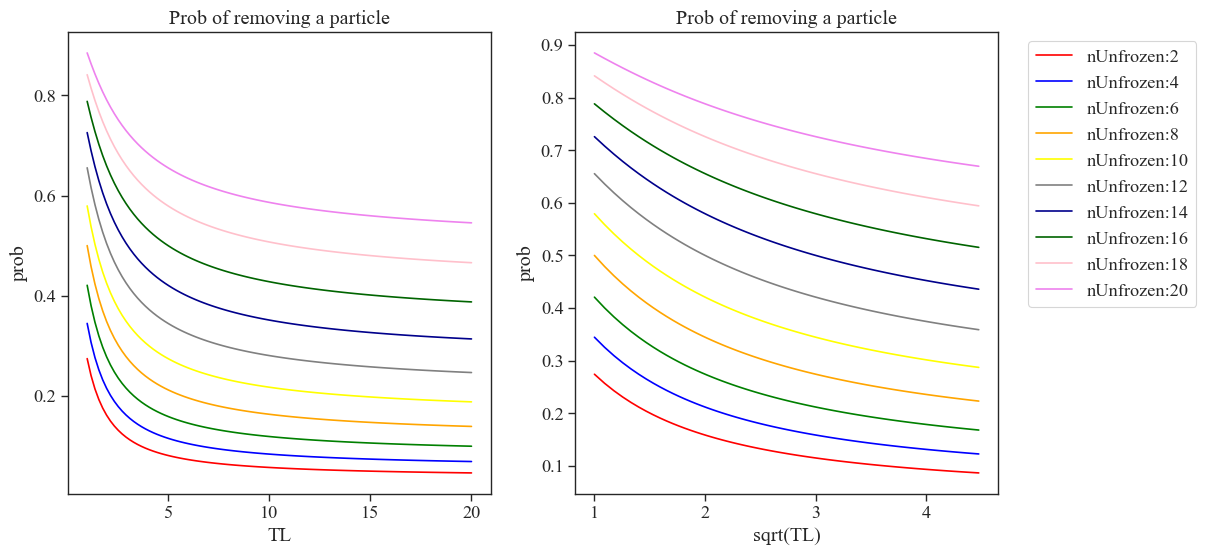

In [ ]:
import numpy as np
steps = 1000
#fig, ax = plt.subplots(4,5, figsize=(20, 10))
muvals = [1 - 1.2/(tl+1) for tl in TL_list]
mu_sqrt = [1 - 1.2/(np.sqrt(tl)+1) for tl in TL_list]
ran_mu = [random.gauss(mu,0.5) for mu in muvals]
ran_sqrt = [random.gauss(mu,0.5) for mu in mu_sqrt]
ran = [ran_mu, ran_sqrt]
mus = [muvals, mu_sqrt]
tls = [TL_list, np.sqrt(TL_list)]
labels = ['TL', 'sqrt(TL)']

muvals = np.linspace(-0.5,1.5,100)
check_points = [nu/20 for nu in range(2,21, 2)]
nUnfrozen = np.arange(2,21,2)
colors = ['r', 'b', 'g', 'orange', 'yellow', 'gray', 'darkblue', 'darkgreen', 'pink', 'violet', 'indigo']
mu_dx = muvals[1] - muvals[0]

from scipy.integrate import quad
def integrand(x, mu):
    return norm.pdf(x, mu, 0.5)


fig, ax  = plt.subplots(ncols=2, figsize=(12,6))
for j,t in enumerate(tls):
    for i,ck in enumerate(check_points):
        p_rem_disb = []
        for m in mus[j]:
            p_not_rem = sum([norm.pdf(mu,m,0.5)*mu_dx for mu in muvals if mu>ck])
            p_rem = 1.0 - p_not_rem
            p_rem = quad(integrand, -np.inf, ck, args=(m))[0]
            p_rem_disb.append(p_rem)

        ax[j].plot(tls[j], p_rem_disb, color=colors[i], label=f'nUnfrozen:{nUnfrozen[i]}')
    ax[j].set(xlabel=labels[j], ylabel='prob', title='Prob of removing a particle')

ax[1].legend(bbox_to_anchor=(1.05, 1))
plt.show()

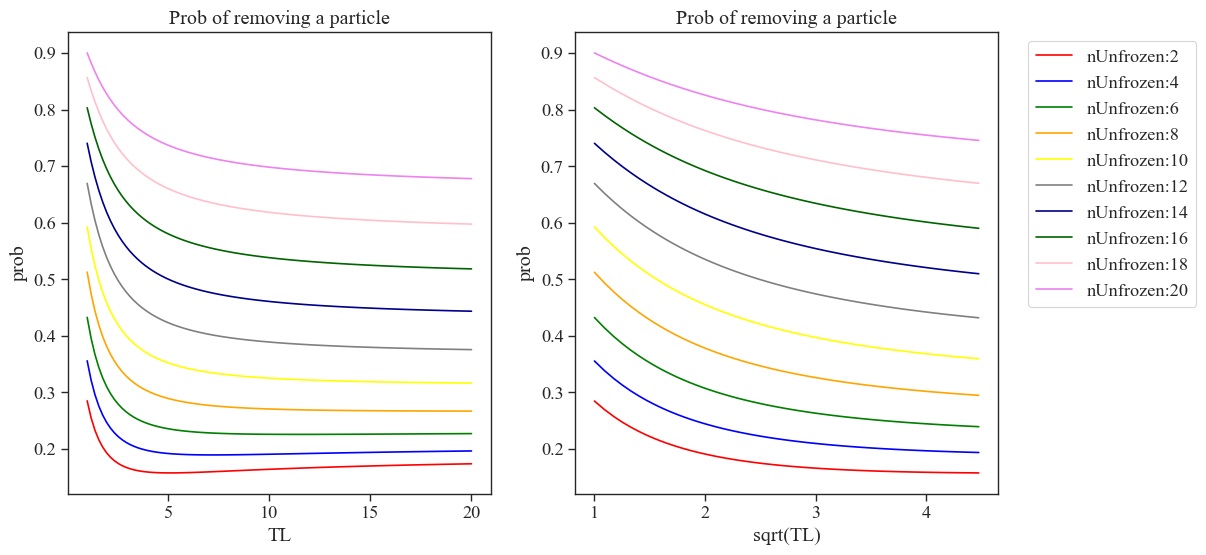

In [ ]:
TL_list = np.linspace(1.0, 20, 100)

import numpy as np
steps = 1000
#fig, ax = plt.subplots(4,5, figsize=(20, 10))
muvals = [1 - 1.2/(tl+1) for tl in TL_list]
mu_sqrt = [1 - 1.2/(np.sqrt(tl)+1) for tl in TL_list]
ran_mu = [random.gauss(mu,0.5) for mu in muvals]
ran_sqrt = [random.gauss(mu,0.5) for mu in mu_sqrt]
ran = [ran_mu, ran_sqrt]
mus = [muvals, mu_sqrt]
tls = [TL_list, np.sqrt(TL_list)]
labels = ['TL', 'sqrt(TL)']

muvals = np.linspace(-0.5,1.5,100)
check_points = [nu/20 for nu in range(2,21, 2)]
nUnfrozen = np.arange(2,21,2)
colors = ['r', 'b', 'g', 'orange', 'yellow', 'gray', 'darkblue', 'darkgreen', 'pink', 'violet', 'indigo']
mu_dx = muvals[1] - muvals[0]

fig, ax  = plt.subplots(ncols=2, figsize=(12,6))
for j,t in enumerate(tls):
    for i,ck in enumerate(check_points):
        p_rem_disb = []
        for m in mus[j]:
            #gauss_rand = norm.rvs(mus[0][0],0.5,100)
            #p_not_add = sum([gauss.pdf(gr,mus[0][0],0.5) for gr in gauss_rand if gr<check_point])
            p_not_rem = sum([norm.pdf(mu,m,0.5)*mu_dx for mu in muvals if mu>ck])
            p_rem = 1.0 - p_not_rem
            p_rem_disb.append(p_rem)

        ax[j].plot(tls[j], p_rem_disb, color=colors[i], label=f'nUnfrozen:{nUnfrozen[i]}')
    ax[j].set(xlabel=labels[j], ylabel='prob', title='Prob of removing a particle')

ax[1].legend(bbox_to_anchor=(1.05, 1))
'''
plt.xlabel('TL')
plt.ylabel('prob')
plt.title('Prob of adding a new particle')
plt.legend(bbox_to_anchor=(1.05, 1))
'''
plt.show()

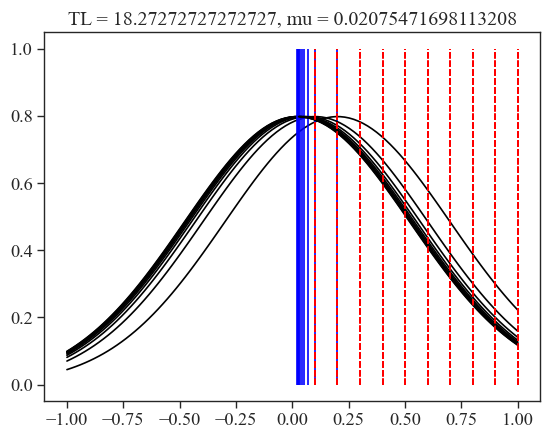

In [ ]:

muvals = np.linspace(-1.0,1.0,100)
check_points = [nu/20 for nu in range(2,21, 2)]
for i in range(0, len(tls[0]), 10):
    proposal_disb = norm.pdf(muvals, mus[0][i], 0.5)
   
    plt.plot(muvals, proposal_disb, color='black', label=f'adding prob')
    plt.vlines(mus[0][i], 0, 1.0, color='blue')
    plt.vlines(check_points, 0, 1.0, color='red', linestyles='--')
    plt.title(f"TL = {tls[0][i]}, mu = {mus[0][i]}")
plt.show()

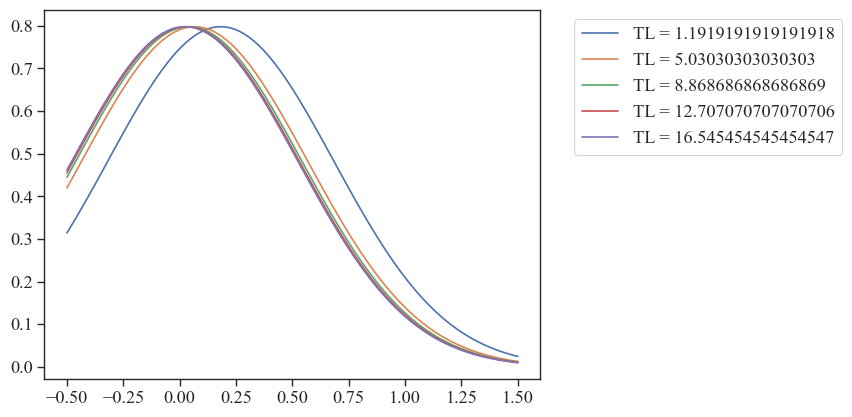

'\nfor i in range(0, len(tls[1]), 20):\n    proposal_disb = norm.pdf(muvals, mus[1][i], 0.5)\n    plt.plot(muvals, proposal_disb, label=f\'sqrt(TL) = {tls[1][i]}\')\n    #rand_pts = random.gauss(mus[0][i],0.5,1000)\n    #llhd_points = norm.pdf(rand_pts, mus[0][i], 0.5)\n    #plt.scatter(rand_pts, llhd_points, c=colors)\n    #plt.vlines(mus[0][i], 0, 1.0, color=\'blue\')\n    #plt.vlines(check_points[0], 0, 1.0, color=\'red\', linestyles=\'--\')\n    #plt.title(f"TL = {tls[0][i]}, mu = {mus[0][i]}")\n\nplt.legend(bbox_to_anchor=(1.05,1.0))\nplt.show()\n'

In [ ]:
from scipy.stats import norm


muvals = np.linspace(-0.5,1.5,100)
check_points = [nu/20 for nu in range(2,21, 2)]
for i in range(1, len(tls[0]), 20):
    proposal_disb_tl = norm.pdf(muvals, mus[0][i], 0.5)
    plt.plot(muvals, proposal_disb_tl, label=f'TL = {tls[0][i]}')
    #rand_pts = random.gauss(mus[0][i],0.5,1000)
    #llhd_points = norm.pdf(rand_pts, mus[0][i], 0.5)
    #plt.scatter(rand_pts, llhd_points, c=colors)
    #plt.vlines(mus[0][i], 0, 1.0, color='blue')
    #plt.vlines(check_points[0], 0, 1.0, color='red', linestyles='--')
    #plt.title(f"TL = {tls[0][i]}, mu = {mus[0][i]}")

plt.legend(bbox_to_anchor=(1.05,1.0))
plt.show()
'''
for i in range(0, len(tls[1]), 20):
    proposal_disb = norm.pdf(muvals, mus[1][i], 0.5)
    plt.plot(muvals, proposal_disb, label=f'sqrt(TL) = {tls[1][i]}')
    #rand_pts = random.gauss(mus[0][i],0.5,1000)
    #llhd_points = norm.pdf(rand_pts, mus[0][i], 0.5)
    #plt.scatter(rand_pts, llhd_points, c=colors)
    #plt.vlines(mus[0][i], 0, 1.0, color='blue')
    #plt.vlines(check_points[0], 0, 1.0, color='red', linestyles='--')
    #plt.title(f"TL = {tls[0][i]}, mu = {mus[0][i]}")

plt.legend(bbox_to_anchor=(1.05,1.0))
plt.show()
'''

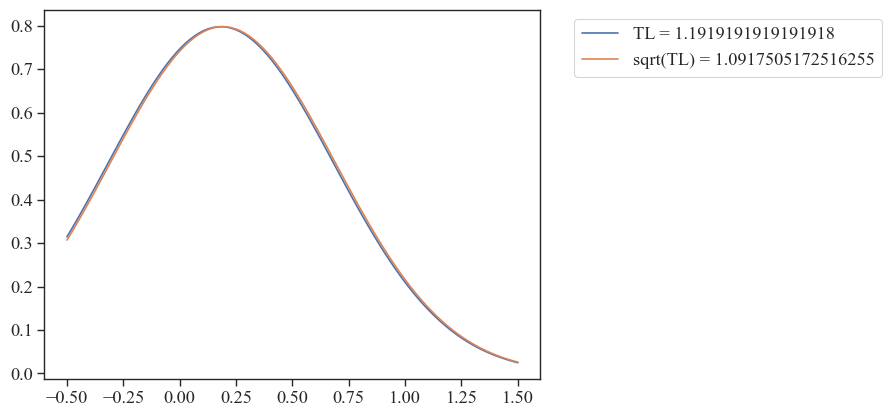

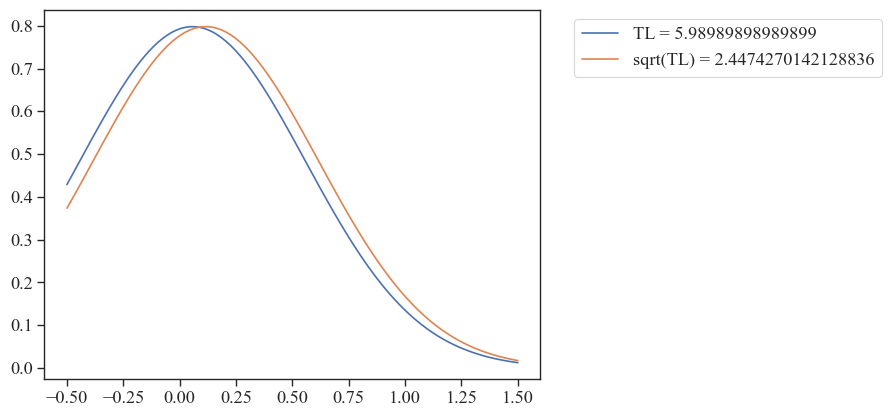

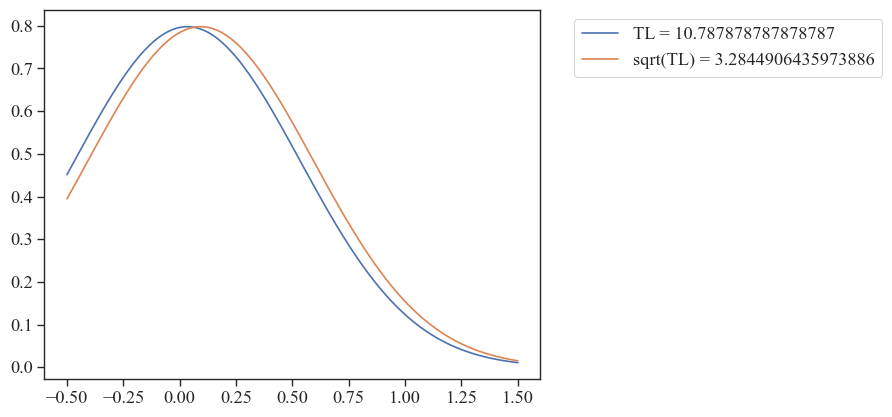

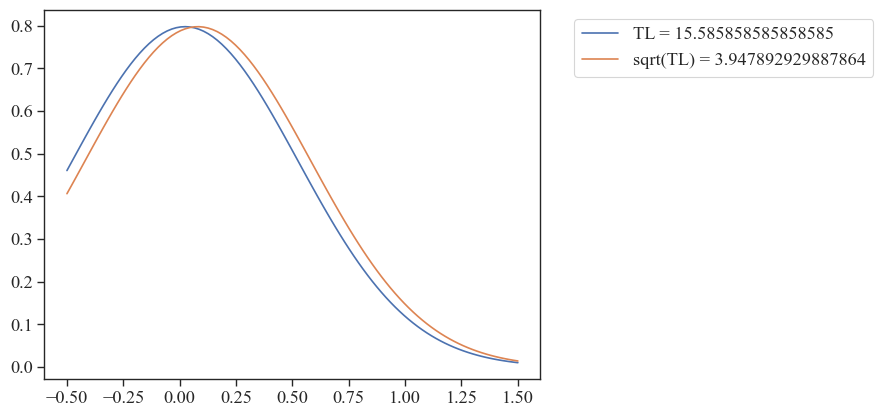

In [ ]:
muvals = np.linspace(-0.5,1.5,100)
check_points = [nu/20 for nu in range(2,21, 2)]
for i in range(1, len(tls[0]), 25):
    proposal_disb_tl = norm.pdf(muvals, mus[0][i], 0.5)
    proposal_disb_sqtl = norm.pdf(muvals, mus[1][i], 0.5)
    plt.plot(muvals, proposal_disb_tl, label=f'TL = {tls[0][i]}')
    plt.plot(muvals, proposal_disb_sqtl, label=f'sqrt(TL) = {tls[1][i]}')
    #rand_pts = random.gauss(mus[0][i],0.5,1000)
    #llhd_points = norm.pdf(rand_pts, mus[0][i], 0.5)
    #plt.scatter(rand_pts, llhd_points, c=colors)
    #plt.vlines(mus[0][i], 0, 1.0, color='blue')
    #plt.vlines(check_points[0], 0, 1.0, color='red', linestyles='--')
    #plt.title(f"TL = {tls[0][i]}, mu = {mus[0][i]}")
    plt.legend(bbox_to_anchor=(1.05,1.0))
    plt.show()



dx = 14.14213562373095


Text(0.5, 1.0, 'nUnfrozen = 2, Tl=1.0')

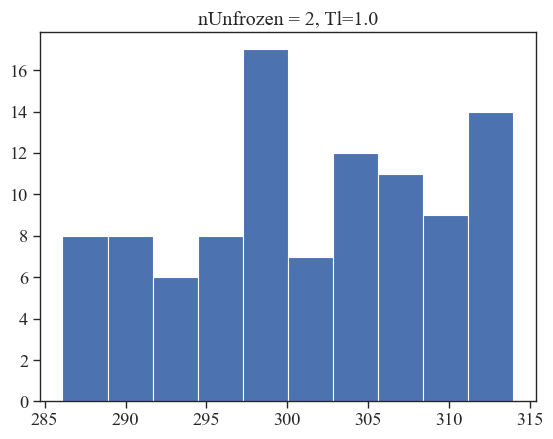

In [ ]:
current_mass = 300
nufr = nUnfrozen[0]
dx = 40/np.sqrt(nufr)/(tls[0][0]+1)
new_mass = [current_mass + random.uniform(-dx,dx) for _ in range(100)]
print(f"dx = {dx}")
plt.hist(new_mass)
plt.title(f"nUnfrozen = {nufr}, Tl={tls[0][0]}")


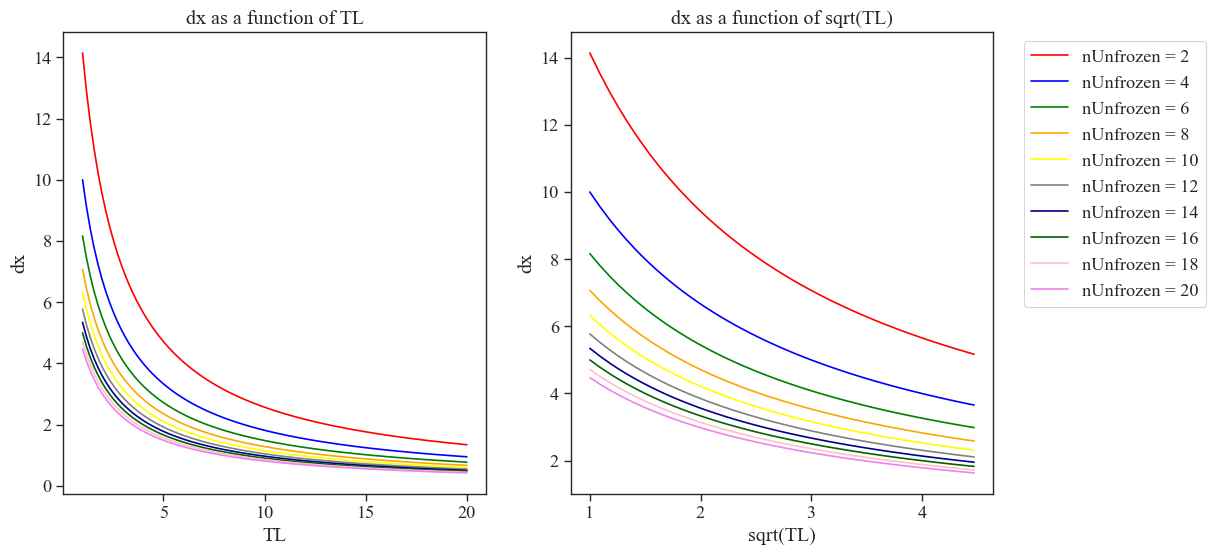

In [ ]:
fig, ax  = plt.subplots(ncols=2, figsize=(12,6))
for j in range(len(tls)):
    for i,nufr in enumerate(nUnfrozen):
        dx_list = []
        for tl in tls[j]:    
            dx = 40/np.sqrt(nufr)/(tl+1)
            dx_list.append(dx)
        ax[j].plot(tls[j], dx_list, label=f"nUnfrozen = {nufr}", color=colors[i])
    ax[j].set(xlabel=labels[j], ylabel='dx', title=f'dx as a function of {labels[j]}')

ax[1].legend(bbox_to_anchor=(1.05,1.0))

plt.show()

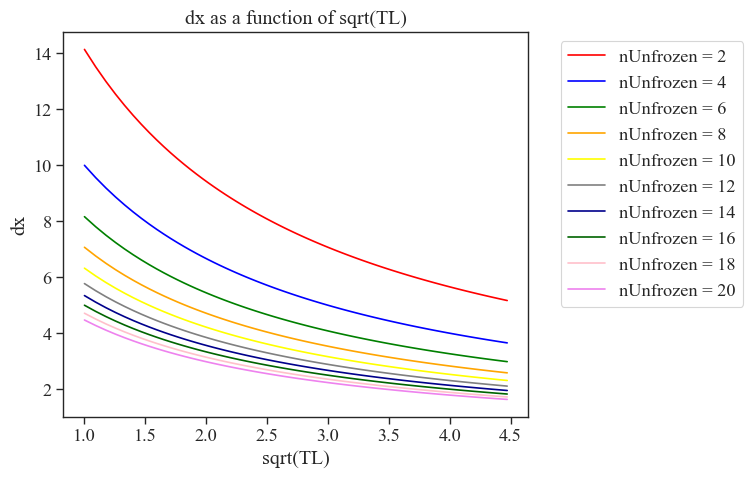

In [ ]:
fig, ax  = plt.subplots(figsize=(6,5))

for i,nufr in enumerate(nUnfrozen):
    dx_list = []
    for tl in tls[1]:    
        dx = 40/np.sqrt(nufr)/(tl+1)
        dx_list.append(dx)
    ax.plot(tls[1], dx_list, label=f"nUnfrozen = {nufr}", color=colors[i])
ax.set(xlabel=labels[1], ylabel='dx', title=f'dx as a function of {labels[1]}')

ax.legend(bbox_to_anchor=(1.05,1.0))

plt.show()